# Cloud-Ansatz: Klassifikation von Supportanfragen via LLM-API

Dieses Notebook bildet den cloudbasierten Teil des Projekts ab. Während der lokale Ansatz
die Tickets über lokal berechnete Sentence-Embeddings und einen lokal trainierten
XGBoost-Klassifikator einer Kategorie zuordnet, wird die Klassifikation hier vollständig
an ein über eine API angesprochenes Large Language Model (Claude) delegiert. Es findet
folglich kein eigenes Training statt; die Inferenz erfolgt entfernt in der Cloud, und die
Ticketdaten werden über das Netz an den Anbieter übertragen.

Damit die beiden Ansätze überhaupt vergleichbar bleiben, wird bewusst **derselbe Datensatz
(Datensatz 4, `dataset-tickets-multi-lang-4-20k.csv`)** und **dieselbe Zielgröße (`queue`)**
verwendet wie im lokalen Notebook, ergänzt um dieselbe Schemabereinigung der Kategorien.

Erhoben werden entlang der im Projekt festgelegten Bewertungskriterien drei Größen:

- **Qualität** der Klassifikation (Accuracy sowie klassenweise Precision/Recall/F1),
- **Kosten** in Form des Token-Verbrauchs je Anfrage und hochgerechnet auf den Gesamtdatensatz,
- **Latenz**, also die Zeitspanne zwischen Absenden der Anfrage und Eintreffen der Antwort.

## Setup und Imports

In [ ]:
# Das offizielle SDK von Anthropic kapselt die HTTP-Kommunikation mit der API.
# In einer frischen Colab-Umgebung muss es einmalig nachinstalliert werden.
%pip install -q anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 938.0/938.0 kB 16.2 MB/s eta 0:00:00


In [ ]:
import os
import json
import time
import statistics
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import anthropic

### API-Schlüssel hinterlegen

Der API-Schlüssel darf nicht im Klartext im Notebook stehen, da dieser sonst beim Teilen
des Notebooks offengelegt würde. Stattdessen wird er aus einer Umgebungsvariablen gelesen.
In Google Colab lässt sich der Schlüssel komfortabel über das Secrets-Panel (Schlüssel-Symbol
in der linken Seitenleiste) unter dem Namen `ANTHROPIC_API_KEY` ablegen; die folgende Zelle
liest ihn von dort bzw. aus der Umgebung aus.

In [ ]:
# Versuche zuerst, den Schlüssel aus dem Colab-Secrets-Speicher zu laden; falls das Notebook
# außerhalb von Colab läuft, wird auf die normale Umgebungsvariable zurückgegriffen.
try:
    from google.colab import userdata
    api_key = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    api_key = os.environ.get("ANTHROPIC_API_KEY")

# Der Client hält die Verbindungsparameter und wird im weiteren Verlauf wiederverwendet.
client = anthropic.Anthropic(api_key=api_key)

# Zentrale Konfiguration: Modellname und Preise an einer Stelle, damit die Kostenrechnung
# weiter unten konsistent bleibt und das Modell bei Bedarf leicht ausgetauscht werden kann.
# Verwendet wird Claude Sonnet 4.6, der direkte Nachfolger des urspruenglich gewaehlten
# Sonnet 4, das zwischenzeitlich abgekuendigt wurde. Sonnet 4.6 teilt dessen Preisstruktur,
# sodass die unten hinterlegten Preise unveraendert bleiben koennen. Fuer eine reine
# Klassifikationsaufgabe waere alternativ das guenstigere Claude Haiku 4.5
# ("claude-haiku-4-5-20251001", 1.00 / 5.00 USD je Mio. Token) eine sinnvolle Wahl; in dem
# Fall muessten die beiden Preiskonstanten entsprechend angepasst werden.
MODEL = "claude-sonnet-4-6"

# Preise des gewaehlten Modells in US-Dollar pro einer Million Token (Stand der Projektarbeit).
# Input- und Output-Token werden vom Anbieter unterschiedlich abgerechnet.
PRICE_INPUT_PER_MTOK = 3.00
PRICE_OUTPUT_PER_MTOK = 15.00

## Datensatz laden (Datensatz 4)

Es wird exakt die Datei verwendet, die auch im lokalen Notebook zum Einsatz kam. Der
Download erfolgt über `kagglehub`; anschließend wird gezielt die 20.000 Zeilen umfassende
multilinguale Variante geladen.

In [ ]:
import kagglehub

# Lädt (bzw. nutzt den Cache) des multilingualen Support-Ticket-Datensatzes.
path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")

# Innerhalb des heruntergeladenen Verzeichnisses liegen mehrere CSV-Dateien; relevant ist
# die 20k-Variante, die im lokalen Ansatz als Datensatz 4 diente.
csv_path = os.path.join(path, "dataset-tickets-multi-lang-4-20k.csv")
df = pd.read_csv(csv_path)

print(f"Geladene Datei : {csv_path}")
print(f"Zeilen gesamt  : {len(df)}")
df.head()

100%|██████████| 16.1M/16.1M [00:00<00:00, 111MB/s]

Extracting files...


Geladene Datei : /root/.cache/kagglehub/datasets/tobiasbueck/multilingual-customer-support-tickets/versions/14/aa_dataset-tickets-multi-lang-5-2-50-version.csv
Zeilen gesamt  : 28587


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


### Aufbereitung der Eingabetexte

Der Klassifikationstext setzt sich aus Betreff (`subject`) und Nachrichtentext (`body`)
zusammen, da beide Felder gemeinsam das aussagekräftigste Signal liefern. Fehlende Werte
werden durch leere Zeichenketten ersetzt, damit die Zusammenführung nicht an `NaN`-Werten
scheitert. Die Zielspalte `queue` enthält die zehn Kategorien, gegen die evaluiert wird.

### Schemabereinigung

Bevor die Stichprobe gezogen und die zulässige Kategorienmenge abgeleitet wird, ist dieselbe
Schemabereinigung anzuwenden, die bereits im lokalen Notebook vorgenommen wurde. Nur so wirkt
ein einheitliches Kategorienschema durchgängig auf den dem Modell vorgegebenen Prompt, auf die
geschichtete Ziehung der Stichprobe und auf die spätere Auswertung, womit die Vergleichbarkeit
beider Ansätze gewahrt bleibt.

Zwei Eingriffe sind erforderlich. Zum einen werden die im Ausgangsdatensatz getrennt geführten
Kategorien `IT Support` und `Technical Support` zu einer gemeinsamen Kategorie
`Technical and IT Support` zusammengeführt, da sich die beiden inhaltlich stark überschneiden
und ihre Trennung im lokalen Ansatz als Quelle systematischer Verwechslungen identifiziert
wurde. Zum anderen wird die Kategorie `Human Resources` vollständig entfernt, da sie für den
betrachteten Anwendungsfall der Kundenanfragen-Klassifikation nicht einschlägig ist.

In [ ]:
# Schemabereinigung, identisch zum lokalen Notebook und zum ML-Prototyp, angewandt vor
# der Stichprobe und der Ableitung der Kategorienliste, damit das bereinigte Schema
# durchgaengig auf Prompt, Stichprobe und Auswertung wirkt.

# Zusammenfuehrung inhaltlich verwandter Kategorien. Schluessel ist die urspruengliche,
# Wert die gebuendelte Zielbezeichnung. Nur tatsaechlich auftretende Kategorien werden
# umgeschrieben; alle uebrigen bleiben unveraendert.
category_merge_map = {
    "IT Support": "Technical and IT Support",
    "Technical Support": "Technical and IT Support",
}

# Kategorien, die vollstaendig entfernt werden, da sie zu schwach besetzt sind und
# thematisch keinen Mehrwert fuer die Klassifikation von Kundenanliegen bieten.
categories_to_drop = ["Human Resources"]

print("Vorhandene Kategorien vor der Ueberarbeitung:")
print(df["queue"].value_counts(), "\n")

# Zusammenfuehrung anwenden und anschliessend die zu schwachen Kategorien herausfiltern.
# Der Index wird zurueckgesetzt, damit die nachfolgende Verarbeitung auf einer
# lueckenlosen Zeilennummerierung aufsetzt.
df["queue"] = df["queue"].replace(category_merge_map)
df = df[~df["queue"].isin(categories_to_drop)].reset_index(drop=True)

print("Kategorien nach der Ueberarbeitung:")
print(df["queue"].value_counts())

Vorhandene Kategorien vor der Ueberarbeitung:
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64 

Kategorien nach der Ueberarbeitung:
queue
Technical and IT Support           11795
Product Support                     5252
Customer Service                    4268
Billing and Payments                2788
Returns and Exchanges               1437
Service Outages and Maintenance     1148
Sales and Pre-Sales                  918
General Inquiry                      405
Name: count, dtype: int64


In [ ]:
# Betreff und Text zu einem einzigen Eingabefeld zusammenführen.
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df["text"] = (df["subject"] + "\n\n" + df["body"]).str.strip()

# Die im Datensatz vorkommenden Kategorien bilden die zulässige Antwortmenge des Modells.
# Diese Liste wird dem LLM im Prompt explizit vorgegeben, damit es keine freien
# Bezeichnungen erfindet, die sich später nicht gegen die wahren Labels vergleichen lassen.
KATEGORIEN = sorted(df["queue"].unique().tolist())
print("Verfügbare Kategorien (queue):")
for k in KATEGORIEN:
    print(" -", k)

Verfügbare Kategorien (queue):
 - Billing and Payments
 - Customer Service
 - General Inquiry
 - Product Support
 - Returns and Exchanges
 - Sales and Pre-Sales
 - Service Outages and Maintenance
 - Technical and IT Support


### Stichprobe ziehen

Eine vollständige Klassifikation aller 20.000 Tickets über die API wäre sowohl zeitlich als
auch finanziell aufwendig. Für die vergleichende Auswertung genügt eine Stichprobe. Damit die
Klassenverteilung der Stichprobe derjenigen des Gesamtdatensatzes entspricht, wird
geschichtet (stratifiziert) gezogen. Der feste Zufallsstartwert sorgt für Reproduzierbarkeit.

In [ ]:
from sklearn.model_selection import train_test_split

# Umfang der Stichprobe. Bei Bedarf kann dieser Wert erhöht werden, um die Schätzungen für
# Qualität, Kosten und Latenz zu stabilisieren - er bestimmt unmittelbar die API-Kosten.
SAMPLE_SIZE = 200

# Geschichtete Ziehung anhand der Zielspalte, damit seltene Kategorien nicht völlig fehlen.
sample_df, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df["queue"],
    random_state=42,
)
sample_df = sample_df.reset_index(drop=True)

print(f"Stichprobengröße: {len(sample_df)}")
sample_df["queue"].value_counts()

Stichprobengröße: 200


,count
queue,
Technical and IT Support,84
Product Support,38
Customer Service,30
Billing and Payments,20
Returns and Exchanges,10
Service Outages and Maintenance,8
Sales and Pre-Sales,7
General Inquiry,3


## Klassifikationsfunktion mit Messung von Qualität, Kosten und Latenz

Die folgende Funktion sendet ein einzelnes Ticket an die API und gibt neben der vorhergesagten
Kategorie auch alle Größen zurück, die für die spätere Auswertung benötigt werden. Der Prompt
gibt die zulässigen Kategorien fest vor und verlangt eine reine JSON-Antwort, damit sich das
Ergebnis maschinell weiterverarbeiten lässt.

Drei Messpunkte sind eingebaut: Die Latenz wird über eine monotone Uhr unmittelbar um den
Netzwerkaufruf herum gemessen; der Token-Verbrauch wird dem `usage`-Feld der Antwort
entnommen, das die Zahl der Eingabe- und Ausgabe-Token getrennt ausweist; aus diesen beiden
Werten lassen sich anschließend die Kosten berechnen. Da Modelle gelegentlich von der streng
geforderten Form abweichen, ist das Parsen der Antwort gegen Fehlerfälle abgesichert.

In [ ]:
# Der Prompt-Rahmen wird einmal als Vorlage definiert. Die Kategorien werden als Aufzählung
# eingesetzt, sodass eine Änderung der Kategorienliste automatisch im Prompt nachgezogen wird.
PROMPT_TEMPLATE = """Du bist ein System zur Klassifikation von Support-Tickets.
Ordne das folgende Ticket genau einer der vorgegebenen Kategorien zu.

Erlaubte Kategorien:
{kategorien}

Antworte ausschließlich mit JSON in exakt diesem Format, ohne zusätzlichen Text:
{{"category": "<eine der erlaubten Kategorien>", "confidence": <Zahl zwischen 0.0 und 1.0>}}

Ticket:
{ticket}"""


def classify_ticket(text: str) -> dict:
    """Klassifiziert ein einzelnes Ticket und misst dabei Latenz und Token-Verbrauch.

    Rückgabe ist ein Dictionary mit der vorhergesagten Kategorie, dem vom Modell genannten
    Konfidenzwert, den verbrauchten Eingabe- und Ausgabe-Token sowie der gemessenen Latenz
    in Sekunden. Tritt ein Fehler auf, wird die Kategorie auf None gesetzt und das Feld
    "error" gefüllt, damit der Gesamtlauf nicht abbricht.
    """
    prompt = PROMPT_TEMPLATE.format(
        kategorien="\n".join(f"- {k}" for k in KATEGORIEN),
        ticket=text,
    )

    # Monotone Uhr, da sie - anders als die Wanduhr - nicht durch Zeitumstellungen springt
    # und damit für Dauermessungen geeignet ist.
    start = time.perf_counter()
    try:
        response = client.messages.create(
            model=MODEL,
            max_tokens=100,
            messages=[{"role": "user", "content": prompt}],
        )
        latency = time.perf_counter() - start

        # Der eigentliche Antworttext steht im ersten Inhaltsblock der Antwort.
        raw = response.content[0].text.strip()

        # Das Modell soll reines JSON liefern; zur Sicherheit wird der relevante Ausschnitt
        # zwischen der ersten geschweiften Klammer und der letzten herausgeschnitten, falls
        # doch erläuternder Text mitgeschickt wurde.
        json_str = raw[raw.find("{"): raw.rfind("}") + 1]
        parsed = json.loads(json_str)

        category = parsed.get("category")
        # Vorhersagen, die nicht zur erlaubten Menge gehören, werden als ungültig markiert,
        # damit sie die Qualitätsmetriken nicht verfälschen.
        if category not in KATEGORIEN:
            category = None

        return {
            "category": category,
            "confidence": parsed.get("confidence"),
            "input_tokens": response.usage.input_tokens,
            "output_tokens": response.usage.output_tokens,
            "latency_s": latency,
            "error": None,
        }
    except Exception as exc:
        # Auch fehlgeschlagene Aufrufe verbrauchen Zeit; diese wird dennoch festgehalten.
        latency = time.perf_counter() - start
        return {
            "category": None,
            "confidence": None,
            "input_tokens": None,
            "output_tokens": None,
            "latency_s": latency,
            "error": str(exc),
        }

### Einzelner Probelauf

Bevor die gesamte Stichprobe verarbeitet wird, empfiehlt sich ein einzelner Aufruf. So lässt
sich prüfen, ob der API-Schlüssel gültig ist und die Antwort wie erwartet geparst wird.

In [ ]:
beispiel = sample_df.iloc[0]
ergebnis = classify_ticket(beispiel["text"])

print("Wahre Kategorie       :", beispiel["queue"])
print("Vorhergesagte Kategorie:", ergebnis["category"])
print("Konfidenz             :", ergebnis["confidence"])
print("Input-Token           :", ergebnis["input_tokens"])
print("Output-Token          :", ergebnis["output_tokens"])
print(f"Latenz                : {ergebnis['latency_s']:.2f} s")

Wahre Kategorie       : Customer Service
Vorhergesagte Kategorie: Sales and Pre-Sales
Konfidenz             : 0.72
Input-Token           : 230
Output-Token          : 21
Latenz                : 1.75 s


## Klassifikation der gesamten Stichprobe

Die Stichprobe wird nun vollständig klassifiziert. Um die Wartezeit zu verkürzen, werden
mehrere Anfragen nebenläufig über einen Thread-Pool abgesetzt; die API verarbeitet parallele
Anfragen, sodass sich die reine Netz- und Inferenzlatenz überlappt. Die Zahl der gleichzeitigen
Anfragen ist bewusst moderat gewählt, um nicht in die Ratenbegrenzung des Anbieters zu laufen.

Wichtig für die spätere Auswertung: Die **summierte Latenz** über alle Tickets gibt den
tatsächlich anfallenden Rechenaufwand wieder, während die **Wanduhr-Gesamtzeit** des Laufs
durch die Parallelisierung deutlich kürzer ausfällt. Beide Größen werden getrennt erfasst.

In [ ]:
# Anzahl gleichzeitig laufender Anfragen. Ein höherer Wert beschleunigt den Lauf, erhöht aber
# das Risiko, an die Ratenbegrenzung zu stoßen.
MAX_WORKERS = 5

results = [None] * len(sample_df)

wall_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Jeder Aufruf wird mit seinem Zeilenindex verknüpft, damit die Ergebnisse trotz
    # nebenläufiger und damit ungeordneter Fertigstellung wieder korrekt zugeordnet werden.
    futures = {
        executor.submit(classify_ticket, row["text"]): idx
        for idx, row in sample_df.iterrows()
    }
    for future in as_completed(futures):
        idx = futures[future]
        results[idx] = future.result()

wall_time = time.perf_counter() - wall_start
print(f"Gesamtlaufzeit (Wanduhr): {wall_time:.1f} s für {len(sample_df)} Tickets")

Gesamtlaufzeit (Wanduhr): 68.0 s für 200 Tickets


In [ ]:
# Die Ergebnisliste wird mit den wahren Labels zu einem Auswertungs-DataFrame zusammengeführt.
results_df = pd.DataFrame(results)
results_df["true_category"] = sample_df["queue"].values
results_df["text"] = sample_df["text"].values

# Fehlgeschlagene oder ungültige Antworten werden gezählt und für die Qualitätsmetriken,
# die eine gültige Vorhersage voraussetzen, separat betrachtet.
n_fehler = results_df["category"].isna().sum()
print(f"Ungültige/fehlgeschlagene Antworten: {n_fehler} von {len(results_df)}")
results_df.head()

Ungültige/fehlgeschlagene Antworten: 0 von 200


,category,confidence,input_tokens,output_tokens,latency_s,error,true_category,text
0,Sales and Pre-Sales,0.72,230,21,1.446347,None,Customer Service,Seeking Information on Safeguarding Medical Da...
1,General Inquiry,0.50,237,19,1.535295,None,Technical and IT Support,Assistance Required for Marketing\n\nDigital m...
2,General Inquiry,0.82,271,19,1.859579,None,Customer Service,Inquiry Regarding Digital Strategies for Busin...
3,Service Outages and Maintenance,0.85,209,23,3.364093,None,Product Support,The data analytics platform experienced an une...
4,Technical and IT Support,0.92,181,20,1.562543,None,Technical and IT Support,Reporting Technical Issue with Applications\n\...


## Auswertung 1: Qualität

Zur Beurteilung der Qualität werden nur die Tickets herangezogen, für die eine gültige
Vorhersage vorliegt. Neben der Gesamtgenauigkeit (Accuracy) wird der vollständige
Klassifikationsbericht ausgegeben, der Precision, Recall und F1-Wert je Kategorie aufschlüsselt.
Dies erlaubt denselben differenzierten Blick wie im lokalen Notebook, in dem sich gezeigt
hatte, dass einzelne Kategorien systematisch schlechter erkannt werden.

In [ ]:
# Nur Zeilen mit gültiger Vorhersage fließen in die Qualitätsmetriken ein.
valid = results_df[results_df["category"].notna()]

accuracy = accuracy_score(valid["true_category"], valid["category"])
print(f"Accuracy (nur gültige Vorhersagen): {accuracy:.3f}")
print()
print("Klassifikationsbericht:")
print(classification_report(valid["true_category"], valid["category"], zero_division=0))

Accuracy (nur gültige Vorhersagen): 0.385

Klassifikationsbericht:
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      0.35      0.52        20
               Customer Service       0.00      0.00      0.00        30
                General Inquiry       0.00      0.00      0.00         3
                Product Support       0.20      0.05      0.08        38
          Returns and Exchanges       0.00      0.00      0.00        10
            Sales and Pre-Sales       0.08      0.43      0.14         7
Service Outages and Maintenance       0.24      0.62      0.34         8
       Technical and IT Support       0.54      0.71      0.61        84

                       accuracy                           0.39       200
                      macro avg       0.26      0.27      0.21       200
                   weighted avg       0.38      0.39      0.34       200



### Konfusionsmatrix

Die Konfusionsmatrix macht sichtbar, welche Kategorien das Modell miteinander verwechselt.
Eine ausgeprägte Diagonale steht für gute Trennschärfe; auffällige Einträge abseits der
Diagonale deuten auf systematische Verwechslungen zwischen inhaltlich verwandten Kategorien hin.

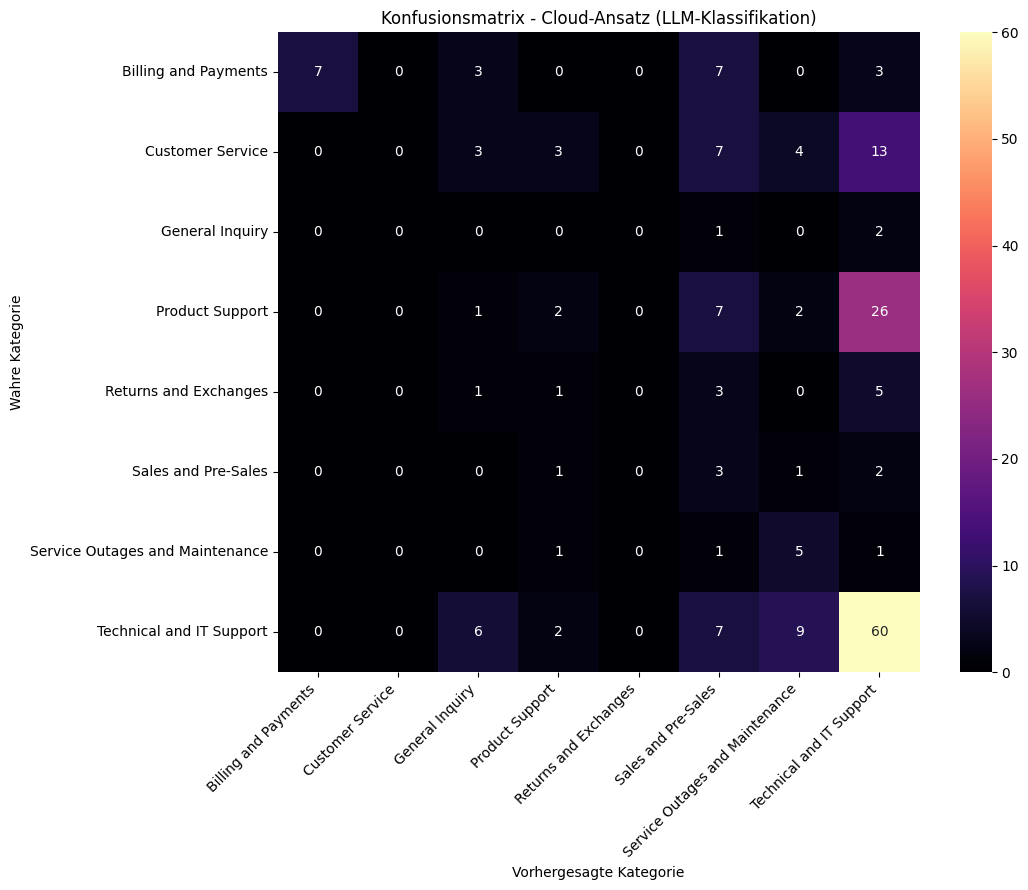

In [ ]:
# Die Matrix wird über alle Kategorien aufgespannt, auch wenn einzelne in der Stichprobe
# selten sind, damit die Achsen mit dem lokalen Notebook vergleichbar bleiben.
labels = KATEGORIEN
cm = confusion_matrix(valid["true_category"], valid["category"], labels=labels)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=labels, yticklabels=labels)
plt.title("Konfusionsmatrix - Cloud-Ansatz (LLM-Klassifikation)")
plt.xlabel("Vorhergesagte Kategorie")
plt.ylabel("Wahre Kategorie")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Auswertung 2: Kosten (Token-Verbrauch)

Die Kosten des Cloud-Ansatzes ergeben sich unmittelbar aus dem Token-Verbrauch, da der
Anbieter pro verarbeitetem Token abrechnet und Eingabe- sowie Ausgabe-Token unterschiedlich
bepreist. Aus dem durchschnittlichen Verbrauch je Ticket lässt sich hochrechnen, was die
Klassifikation des gesamten Datensatzes von 20.000 Tickets kosten würde - eine Zahl, die im
Vergleich mit den (im lokalen Fall vor allem als Rechenzeit anfallenden) Kosten des lokalen
Ansatzes aussagekräftig ist.

In [ ]:
# Nur erfolgreiche Aufrufe besitzen Token-Angaben.
mit_tokens = results_df[results_df["input_tokens"].notna()]

summe_input = int(mit_tokens["input_tokens"].sum())
summe_output = int(mit_tokens["output_tokens"].sum())
mittel_input = mit_tokens["input_tokens"].mean()
mittel_output = mit_tokens["output_tokens"].mean()

# Kosten aus Token-Zahl und Preis je Million Token. Input und Output getrennt gewichtet.
kosten_stichprobe = (
    summe_input / 1_000_000 * PRICE_INPUT_PER_MTOK
    + summe_output / 1_000_000 * PRICE_OUTPUT_PER_MTOK
)

# Mittlere Kosten je Ticket als Grundlage für die Hochrechnung.
kosten_pro_ticket = kosten_stichprobe / len(mit_tokens)
hochrechnung_voll = kosten_pro_ticket * len(df)

print(f"Token gesamt (Stichprobe) : {summe_input} Input + {summe_output} Output")
print(f"Token im Mittel je Ticket : {mittel_input:.1f} Input + {mittel_output:.1f} Output")
print(f"Kosten Stichprobe ({len(mit_tokens)} Tickets): ${kosten_stichprobe:.4f}")
print(f"Kosten je Ticket          : ${kosten_pro_ticket:.6f}")
print(f"Hochrechnung auf {len(df)} Tickets: ${hochrechnung_voll:.2f}")

Token gesamt (Stichprobe) : 52861 Input + 4172 Output
Token im Mittel je Ticket : 264.3 Input + 20.9 Output
Kosten Stichprobe (200 Tickets): $0.2212
Kosten je Ticket          : $0.001106
Hochrechnung auf 28011 Tickets: $30.97


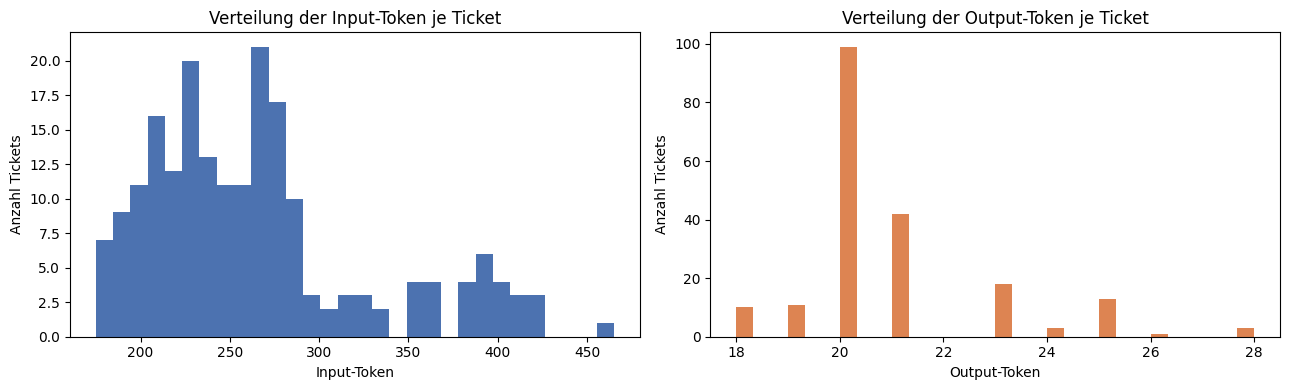

In [ ]:
# Verteilung des Token-Verbrauchs je Ticket. Die Eingabe-Token dominieren erwartungsgemäß,
# da der Prompt samt Ticketinhalt deutlich länger ist als die knappe JSON-Antwort.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(mit_tokens["input_tokens"], bins=30, color="#4c72b0")
ax1.set_title("Verteilung der Input-Token je Ticket")
ax1.set_xlabel("Input-Token")
ax1.set_ylabel("Anzahl Tickets")

ax2.hist(mit_tokens["output_tokens"], bins=30, color="#dd8452")
ax2.set_title("Verteilung der Output-Token je Ticket")
ax2.set_xlabel("Output-Token")
ax2.set_ylabel("Anzahl Tickets")

plt.tight_layout()
plt.show()

## Auswertung 3: Latenz

Die Latenz beschreibt die Zeit von der Absendung einer Anfrage bis zum Eintreffen der Antwort.
Für eine belastbare Einordnung werden nicht nur der Mittelwert, sondern auch der Median und die
oberen Perzentile betrachtet, da die Latenz von API-Aufrufen typischerweise rechtsschief
verteilt ist: einzelne langsame Anfragen ziehen den Mittelwert nach oben, während der Median
das gewöhnliche Verhalten besser abbildet. Das 95.-Perzentil gibt an, wie lange die langsamsten
Anfragen dauern - eine im Betrieb relevante Größe für die Auslegung von Zeitlimits.

In [ ]:
latenzen = results_df["latency_s"].dropna().tolist()

mittel = statistics.mean(latenzen)
median = statistics.median(latenzen)
p95 = sorted(latenzen)[int(0.95 * len(latenzen)) - 1]
minimum = min(latenzen)
maximum = max(latenzen)

print(f"Latenz Mittelwert : {mittel:.2f} s")
print(f"Latenz Median     : {median:.2f} s")
print(f"Latenz 95-Perzentil: {p95:.2f} s")
print(f"Latenz Min / Max  : {minimum:.2f} s / {maximum:.2f} s")
print()
# Summierte Latenz = sequenzieller Aufwand; Wanduhrzeit war durch Parallelisierung kürzer.
print(f"Summierte Latenz (sequenziell gedacht): {sum(latenzen):.1f} s")
print(f"Tatsächliche Wanduhrzeit des Laufs     : {wall_time:.1f} s")

Latenz Mittelwert : 1.60 s
Latenz Median     : 1.38 s
Latenz 95-Perzentil: 2.98 s
Latenz Min / Max  : 1.09 s / 6.01 s

Summierte Latenz (sequenziell gedacht): 319.1 s
Tatsächliche Wanduhrzeit des Laufs     : 68.0 s


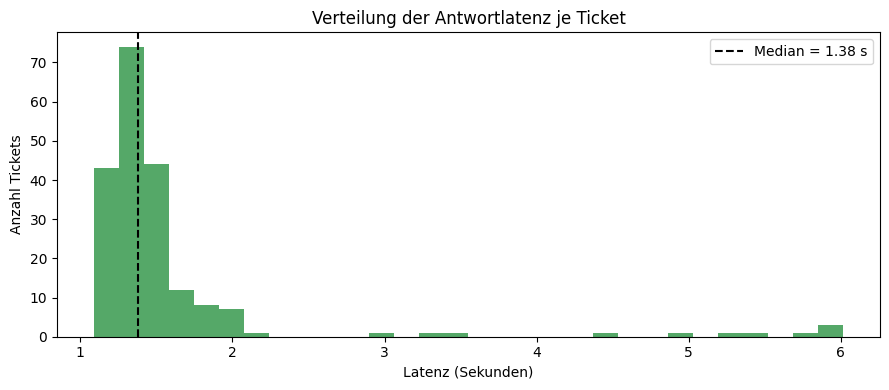

In [ ]:
# Histogramm der Latenzverteilung mit eingezeichnetem Median zur schnellen Orientierung.
plt.figure(figsize=(9, 4))
plt.hist(latenzen, bins=30, color="#55a868")
plt.axvline(median, color="black", linestyle="--", label=f"Median = {median:.2f} s")
plt.title("Verteilung der Antwortlatenz je Ticket")
plt.xlabel("Latenz (Sekunden)")
plt.ylabel("Anzahl Tickets")
plt.legend()
plt.tight_layout()
plt.show()

## Zusammenfassung der Messgrößen

Die folgende Tabelle bündelt die drei erhobenen Kennzahlen, sodass sie unmittelbar in den
Vergleich mit dem lokalen Ansatz übernommen werden können.

In [ ]:
zusammenfassung = pd.DataFrame([
    {"Kriterium": "Accuracy", "Wert": f"{accuracy:.3f}"},
    {"Kriterium": "Kosten je Ticket (USD)", "Wert": f"{kosten_pro_ticket:.6f}"},
    {"Kriterium": f"Hochrechnung {len(df)} Tickets (USD)", "Wert": f"{hochrechnung_voll:.2f}"},
    {"Kriterium": "Latenz Median (s)", "Wert": f"{median:.2f}"},
    {"Kriterium": "Latenz 95-Perzentil (s)", "Wert": f"{p95:.2f}"},
    {"Kriterium": "Ungültige Antworten", "Wert": f"{n_fehler} / {len(results_df)}"},
])
zusammenfassung

,Kriterium,Wert
0,Accuracy,0.385
1,Kosten je Ticket (USD),0.001106
2,Hochrechnung 28011 Tickets (USD),30.97
3,Latenz Median (s),1.38
4,Latenz 95-Perzentil (s),2.98
5,Ungültige Antworten,0 / 200


### Einordnung

Der Cloud-Ansatz erreicht die Klassifikation ohne eigenes Training und ohne lokal vorgehaltene
Modellgewichte; der Aufwand verlagert sich vollständig auf die je Anfrage anfallenden Token-Kosten
und die Netzlatenz. Dem steht der lokale Ansatz gegenüber, dessen Hauptaufwand einmalig im
Training und im Vorhalten der Embedding- sowie Klassifikationsmodelle liegt, der dafür aber ohne
laufende Token-Kosten und ohne Übertragung der Ticketdaten an einen externen Anbieter auskommt.
Die hier gemessenen Werte für Qualität, Kosten und Latenz bilden die empirische Grundlage, um
die im Projekt aufgeworfenen Trade-offs - insbesondere zwischen Datenschutz und Kontrolle auf der
einen sowie Qualität und Skalierbarkeit auf der anderen Seite - am konkreten Anwendungsfall
sichtbar zu machen.

## Ergänzung: Hochrechnung mit dem Batch-API-Rabatt

Die bisher ausgewiesene Hochrechnung auf den Gesamtdatensatz beruht auf den Standardpreisen
synchroner Anfragen, also genau jener Aufrufe, die das Notebook im Echtzeitbetrieb absetzt und
deren Latenz weiter oben gemessen wurde. Für eine reine Kostenbetrachtung des vollständigen
Datensatzes existiert mit der Message-Batches-API jedoch ein günstigerer Weg, der an dieser
Stelle der Vollständigkeit halber quantifiziert wird.

Bei der Batch-Verarbeitung werden die Anfragen nicht einzeln und unmittelbar, sondern gesammelt
und asynchron verarbeitet; die Ergebnisse liegen innerhalb von bis zu 24 Stunden vor. Für diesen
Verzicht auf sofortige Antwort gewährt der Anbieter einen Preisnachlass von fünfzig Prozent auf
die Token-Preise, und zwar ohne Unterschied in der Qualität der Antworten, da dasselbe Modell
dieselbe Klassifikation berechnet; einzig der Zeitpunkt der Auslieferung verschiebt sich.

Methodisch ist diese Option bewusst von den oben erhobenen Messgrößen getrennt zu halten. Für
das Bewertungskriterium **Latenz** ist die Batch-Verarbeitung ungeeignet, da eine Antwortzeit im
Bereich von Stunden nicht mit der sekundengenauen Latenz des synchronen Betriebs vergleichbar
ist und die Fragestellung des interaktiven Klassifizierens verfehlt. Für das Bewertungskriterium
**Kosten** hingegen stellt sie die realistischere Untergrenze dar, sobald die Klassifikation des
gesamten Datensatzes als Stapelverarbeitung im Hintergrund gedacht wird, bei der es auf wenige
Stunden Wartezeit nicht ankommt. Die folgende Rechnung weist daher beide Szenarien nebeneinander
aus, sodass in der vergleichenden Diskussion sauber zwischen dem latenzkritischen und dem rein
kostenorientierten Fall unterschieden werden kann.

In [ ]:
# Rabattfaktor der Message-Batches-API: fuenfzig Prozent auf die Standard-Token-Preise.
BATCH_RABATT = 0.50

# Die Batch-Hochrechnung skaliert die bereits ermittelten Vollkosten linear mit dem Rabatt.
# Da Input- und Output-Token denselben prozentualen Nachlass erhalten, genuegt die Anwendung
# des Faktors auf die zuvor berechnete Hochrechnung des synchronen Betriebs.
hochrechnung_batch = hochrechnung_voll * (1 - BATCH_RABATT)
kosten_pro_ticket_batch = kosten_pro_ticket * (1 - BATCH_RABATT)

print("Vergleich der Hochrechnung auf den Gesamtdatensatz")
print("-" * 55)
print(f"Tickets gesamt                       : {len(df)}")
print()
print("Synchron (latenzkritisch, oben gemessen):")
print(f"  Kosten je Ticket                   : ${kosten_pro_ticket:.6f}")
print(f"  Hochrechnung {len(df)} Tickets        : ${hochrechnung_voll:.2f}")
print()
print("Batch-API (asynchron, bis zu 24 h Wartezeit):")
print(f"  Kosten je Ticket                   : ${kosten_pro_ticket_batch:.6f}")
print(f"  Hochrechnung {len(df)} Tickets        : ${hochrechnung_batch:.2f}")
print()
print(f"Ersparnis durch Batch-Verarbeitung   : ${hochrechnung_voll - hochrechnung_batch:.2f} "
      f"({BATCH_RABATT*100:.0f} %)")

Vergleich der Hochrechnung auf den Gesamtdatensatz
-------------------------------------------------------
Tickets gesamt                       : 28011

Synchron (latenzkritisch, oben gemessen):
  Kosten je Ticket                   : $0.001106
  Hochrechnung 28011 Tickets        : $30.97

Batch-API (asynchron, bis zu 24 h Wartezeit):
  Kosten je Ticket                   : $0.000553
  Hochrechnung 28011 Tickets        : $15.49

Ersparnis durch Batch-Verarbeitung   : $15.49 (50 %)


Die Gegenüberstellung verdeutlicht, dass die Wahl zwischen synchroner und asynchroner
Verarbeitung kein technisches Detail, sondern eine unmittelbar an den Anwendungsfall gebundene
Entscheidung ist. Verlangt der Einsatz eine sofortige Rückmeldung, etwa weil eingehende Tickets
im Moment ihres Eintreffens einer Warteschlange zugeordnet werden sollen, ist der synchrone Weg
samt der dort gemessenen Latenz maßgeblich. Lässt sich die Klassifikation dagegen als nächtlicher
Stapellauf organisieren, halbieren sich die Token-Kosten, womit sich die Position des
Cloud-Ansatzes in der Kostendimension gegenüber dem lokalen Ansatz spürbar verschiebt. Beide
Werte sind daher in der abschließenden Bewertung getrennt zu führen und jeweils dem passenden
Szenario zuzuordnen.